In [1]:
import pandas as pd
import numpy as np
perch_full = pd.read_csv(r'https://raw.githubusercontent.com/rickiepark/hg-mldl/master/perch_full.csv')
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

(42, 3) (14,)
(42, 56)


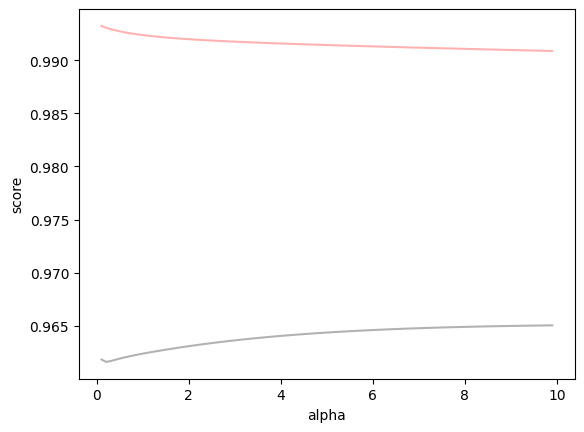

0.9925195688182668
0.9644936959999492
49
[ 0.         13.98294582 12.11307283 11.44830581 12.96392001 11.46032804
 11.68885808  9.86931983 10.23417745 10.7061994  10.58764235  9.32240389
  9.87299913  7.97626504  8.6193657   9.38188147  6.56487919  7.29695214
  8.15516564  9.11070162  7.6452239   6.59594915  7.2568594   5.46850005
  6.20598692  7.06945676  4.26827162  5.08258108  6.02690965  7.08475831
  3.00417845  3.89583618  4.9204604   6.05988821  7.29020904  4.53438044
  3.67733323  4.34381211  2.74515637  3.47975244  4.34289685  1.73848856
  2.5433566   3.48007503  4.54129389  0.66133325  1.53857529  2.55040568
  3.6881723   4.93793005 -0.47869841  0.47302471  1.56148807  2.77640793
  4.10167765  5.51489948]


array(['length', 'length^2', ' height', 'length  width', 'length  height',
       ' width', ' width^2', 'length^3', ' height  width',
       'length^2  width', ' height^2', 'length  width^2',
       'length^2  height', ' width^3', 'length  height  width',
       ' height  width^2', 'length  height^2', 'length^4',
       ' height^2  width', ' width^4', 'length^3  width',
       'length  width^3', 'length^2  width^2', 'length^3  height',
       ' height^3', 'length^2  height  width', ' height  width^3',
       'length  height  width^2', ' width^5', 'length^2  height^2',
       'length  height^2  width', 'length  width^4', ' height^2  width^2',
       'length^2  width^3', 'length^5', 'length^4  width',
       'length^3  width^2', 'length  height^3', ' height  width^4',
       ' height^3  width', 'length  height  width^3', 'length^4  height',
       'length^2  height  width^2', 'length^3  height  width',
       ' height^4', ' height^2  width^3', 'length^3  height^2',
       'length  height

In [58]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(perch_full, perch_weight)
print(train_input.shape, test_target.shape)

from sklearn.preprocessing import PolynomialFeatures
p = PolynomialFeatures(degree=5)
p.fit(train_input)
train_input2 = p.transform(train_input)
test_input2 = p.transform(test_input)
print(train_input2.shape)

from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input2)
train_input_sc = ss.transform(train_input2)
test_input_sc = ss.transform(test_input2)

#릿지 규제 적용. 계수의 절댓값 기준으로 규제. 일반적 선호.
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(train_input_sc, train_target)
ridge.score(train_input_sc, train_target)
ridge.score(test_input_sc, test_target)

import matplotlib.pyplot as plt
alpha_list = np.arange(0.1, 10, 0.1)
train_score = []
test_score = []
for a in alpha_list:
    ridge=Ridge(alpha=a)
    ridge.fit(train_input_sc, train_target)
    train_score.append(ridge.score(train_input_sc, train_target))
    test_score.append(ridge.score(test_input_sc, test_target))
plt.plot([a for a in alpha_list], train_score, c='red', alpha=0.3, label='train')
plt.plot([a for a in alpha_list], test_score, c='black', alpha=0.3, label='test')
plt.xlabel('alpha')
plt.ylabel('score')
plt.show()
train_score
test_score

from sklearn.linear_model import Lasso
lasso = Lasso()
lasso.fit(train_input_sc, train_target)
print(lasso.score(train_input_sc, train_target))
print(lasso.score(test_input_sc, test_target))
print(np.sum(lasso.coef_==0))

print(ridge.coef_)
idx = np.argsort(ridge.coef_)[::-1]
a = p.get_feature_names_out()
a[idx]